# 01 — Model & Sampling Strategy

**Repository:** `stochastic-physics-simulations`  
**Notebook:** Conceptual walkthrough of the MCMC setup, interaction model, and convergence diagnostics.

---

This notebook covers:
1. Why MCMC for complex system simulation
2. The pair interaction model
3. The Metropolis-Hastings algorithm
4. Proposal distribution and acceptance rate
5. Convergence and mixing diagnostics
6. Simulation parameters reference

## Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')


plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'lines.linewidth': 2.0,
})

---
## 1. Why Markov Chain Monte Carlo?

Consider a system of **N particles** in a 3D box. The state of the system is a point in a
**3N-dimensional configuration space**. We want to compute thermal averages of the form:

$$\langle A \rangle = \frac{\int A(\mathbf{r}) \, e^{-U(\mathbf{r})/kT} \, d\mathbf{r}}{\int e^{-U(\mathbf{r})/kT} \, d\mathbf{r}}$$

Direct numerical integration is impossible — the state space grows exponentially with N.  
**MCMC solves this by importance sampling**: instead of integrating uniformly over all configurations,
we draw samples proportional to the Boltzmann weight $e^{-U/kT}$, concentrating effort where the
distribution has mass.

The result is a **Markov chain** whose stationary distribution is exactly the target distribution.
Sample averages over the chain converge to the true thermal averages as the chain grows.

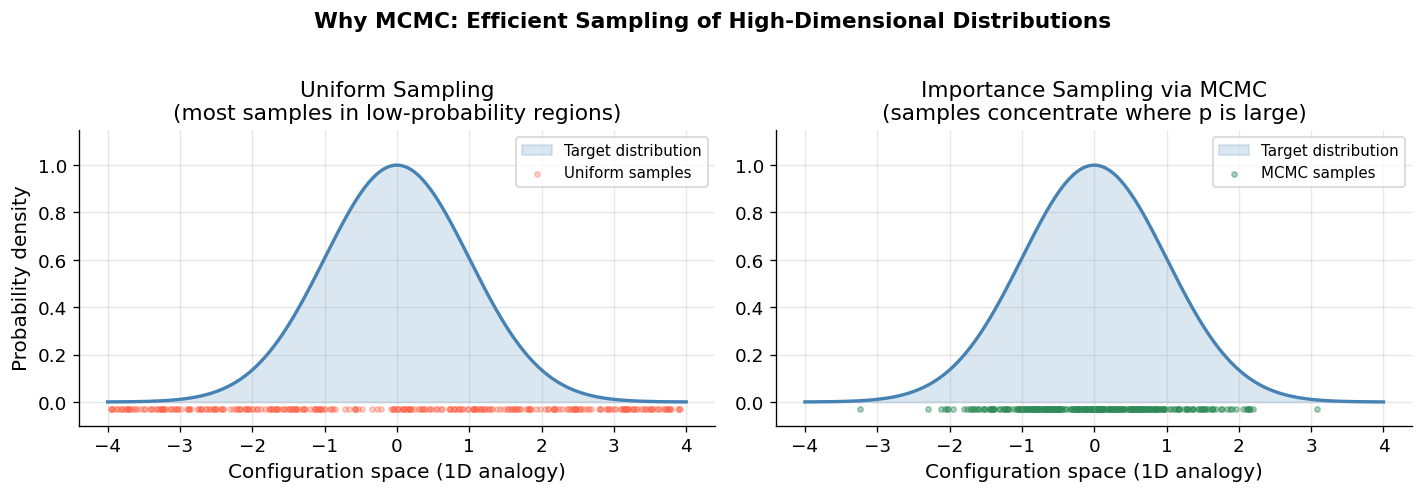

In [3]:
# importance sampling vs. uniform sampling
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# uniform sampling — most samples wasted in low-probability regions
x = np.linspace(-4, 4, 500)
target = np.exp(-0.5 * x**2)          # Gaussian target (Boltzmann analogy)
uniform_samples = np.random.uniform(-4, 4, 300)

axes[0].fill_between(x, target, alpha=0.2, color='steelblue', label='Target distribution')
axes[0].plot(x, target, color='steelblue')
axes[0].scatter(uniform_samples, np.zeros_like(uniform_samples) - 0.03,
                alpha=0.3, s=10, color='tomato', label='Uniform samples')
axes[0].set_title('Uniform Sampling\n(most samples in low-probability regions)')
axes[0].set_xlabel('Configuration space (1D analogy)')
axes[0].set_ylabel('Probability density')
axes[0].legend(fontsize=9)
axes[0].set_ylim(-0.1, 1.15)

# importance sampling (MCMC) — samples concentrate where it matters
mcmc_samples = np.random.randn(300)    # samples from the target itself

axes[1].fill_between(x, target, alpha=0.2, color='steelblue', label='Target distribution')
axes[1].plot(x, target, color='steelblue')
axes[1].scatter(mcmc_samples, np.zeros_like(mcmc_samples) - 0.03,
                alpha=0.4, s=10, color='seagreen', label='MCMC samples')
axes[1].set_title('Importance Sampling via MCMC\n(samples concentrate where p is large)')
axes[1].set_xlabel('Configuration space (1D analogy)')
axes[1].legend(fontsize=9)
axes[1].set_ylim(-0.1, 1.15)

plt.suptitle('Why MCMC: Efficient Sampling of High-Dimensional Distributions', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 2. The Pair Interaction Model

Particles interact through a **continuous pair potential** $u(r)$ that depends only on the
center-to-center distance $r$. The model used here is the **Mie(50,49)** potential:

$$u(r) = C \cdot \varepsilon \left[ \left(\frac{\sigma}{r}\right)^{50} - \left(\frac{\sigma}{r}\right)^{49} \right] + \varepsilon, \quad r < r_c$$

where $C = 50 \cdot (50/49)^{49}$, $\sigma$ is the particle diameter (collision distance),
and $\varepsilon$ is the well depth. The potential is **truncated and shifted** at $r_c$
so that $u(r_c) = 0$, avoiding energy discontinuities.

The steep repulsive wall ($r^{-50}$) makes this potential an excellent continuous approximation
to the **hard-sphere model**, while the shallow attractive well ($r^{-49}$) captures short-range
cohesion. In the limit of infinite exponents, it converges to a true hard sphere.

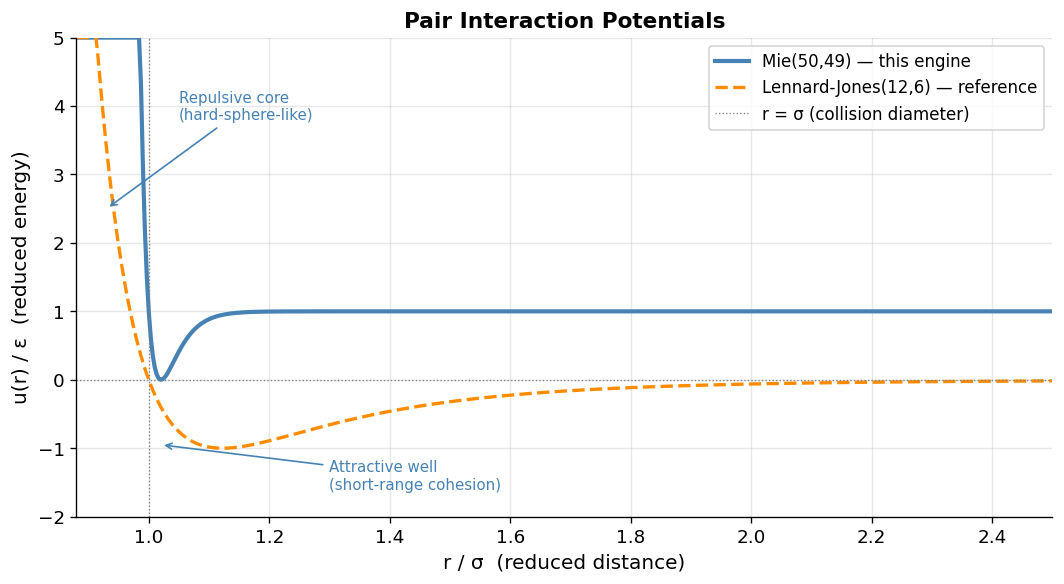

Mie(50,49) minimum at r/σ ≈ 1.0196,  u(r_min)/ε ≈ 0.0008
LJ(12,6)   minimum at r/σ ≈ 1.1225,  u(r_min)/ε = -1.0000


In [4]:
def mie_potential(r, eps=1.0, sigma=1.0):
    """Mie(50,49) pair potential — continuous hard-sphere approximation."""
    C = 50.0 * (50.0 / 49.0)**49
    x = sigma / r
    return C * eps * (x**50 - x**49) + eps

def lj_potential(r, eps=1.0, sigma=1.0):
    """Lennard-Jones(12,6) potential — classic reference model."""
    x = sigma / r
    return 4 * eps * (x**12 - x**6)

# potentials for comparison
r = np.linspace(0.88, 2.5, 500)

u_mie = mie_potential(r)
u_lj  = lj_potential(r)

# visualization
u_mie_clip = np.clip(u_mie, -2, 5)
u_lj_clip  = np.clip(u_lj,  -2, 5)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(r, u_mie_clip, color='steelblue',  label='Mie(50,49) — this engine', linewidth=2.5)
ax.plot(r, u_lj_clip,  color='darkorange', label='Lennard-Jones(12,6) — reference',
        linewidth=2.0, linestyle='--')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.axvline(1, color='gray', linewidth=0.8, linestyle=':', label='r = σ (collision diameter)')

# features
ax.annotate('Repulsive core\n(hard-sphere-like)', xy=(0.93, 2.5),
            xytext=(1.05, 3.8), fontsize=9, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue'))
ax.annotate('Attractive well\n(short-range cohesion)', xy=(1.02, -0.95),
            xytext=(1.3, -1.6), fontsize=9, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue'))

ax.set_xlabel('r / σ  (reduced distance)')
ax.set_ylabel('u(r) / ε  (reduced energy)')
ax.set_title('Pair Interaction Potentials', fontweight='bold')
ax.set_xlim(0.88, 2.5)
ax.set_ylim(-2, 5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# key values
r_min_mie = r[np.argmin(u_mie_clip)]
print(f"Mie(50,49) minimum at r/σ ≈ {r_min_mie:.4f},  u(r_min)/ε ≈ {mie_potential(r_min_mie):.4f}")
print(f"LJ(12,6)   minimum at r/σ ≈ {2**(1/6):.4f},  u(r_min)/ε = -1.0000")

**Key difference:** The Mie(50,49) well is much narrower and shallower than LJ(12,6),
making it a near-perfect hard-sphere model. The total energy of the system is:

$$U = \sum_{i < j} u(r_{ij})$$

summed over all unique particle pairs — the central quantity the MCMC engine samples.

---
## 3. The Metropolis-Hastings Algorithm

The engine implements the classic **Metropolis-Hastings** algorithm for the NVT (canonical)
ensemble, where N (particles), V (volume), and T (temperature) are fixed.

### Algorithm — one MCMC step:

```
1. Select particle i at random (uniform over 1..N)
2. Propose new position:  x_new = x_old + δ · U(-0.5, 0.5)
                          (same for y and z)
3. Apply periodic boundary conditions
4. Compute ΔU = U(x_new) − U(x_old)
5. Accept / reject:
       if ΔU ≤ 0  →  accept always          (move lowers energy)
       if ΔU > 0  →  accept with prob exp(−ΔU / T)   (Boltzmann factor)
6. If accepted: update position, update total energy
7. Accumulate statistics
```

The key insight is that **detailed balance** is satisfied:
$$p(\mathbf{r}) \cdot T(\mathbf{r} \to \mathbf{r}') = p(\mathbf{r}') \cdot T(\mathbf{r}' \to \mathbf{r})$$

which guarantees the chain's stationary distribution is the target Boltzmann distribution.

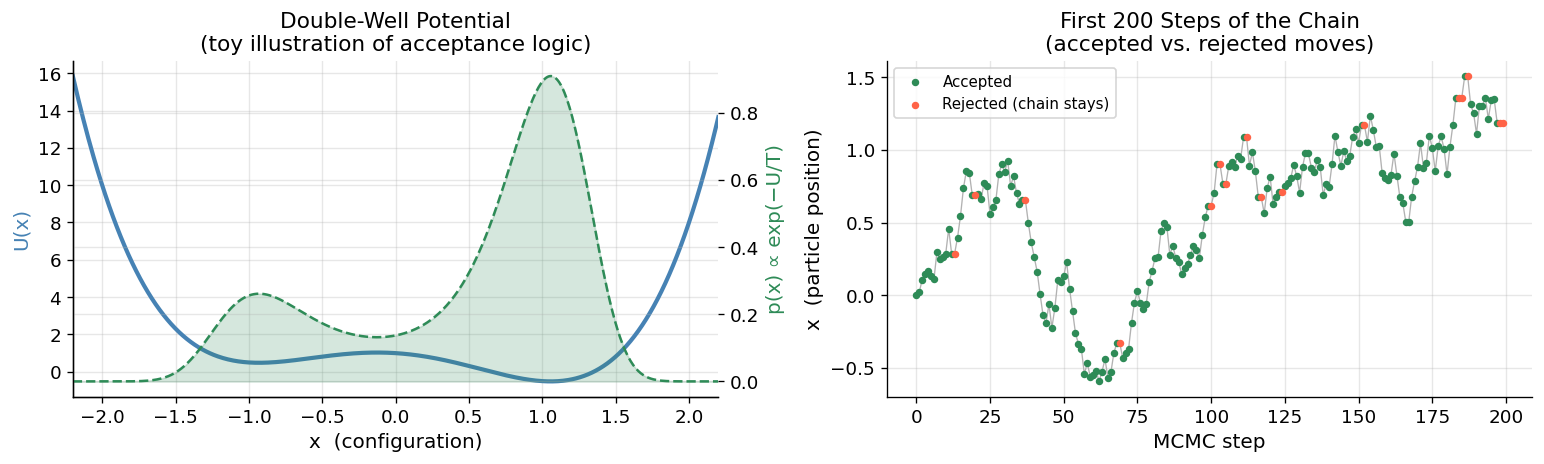

Overall acceptance rate: 89.74%  (target: 30–50%)


In [5]:
# acceptance/rejection logic with a 1D toy example
np.random.seed(0)

def U_toy(x):
    """Simple double-well potential for illustration."""
    return (x**2 - 1)**2 - 0.5 * x

T = 0.8
n_steps = 3000
displ = 0.4
x = 0.0
trajectory = [x]
accepted = [True]

for _ in range(n_steps):
    x_new = x + displ * (np.random.random() - 0.5)
    dU = U_toy(x_new) - U_toy(x)
    if dU <= 0 or np.random.random() < np.exp(-dU / T):
        x = x_new
        accepted.append(True)
    else:
        accepted.append(False)
    trajectory.append(x)

trajectory = np.array(trajectory)
accepted   = np.array(accepted)


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# potential + sampled distribution
x_grid = np.linspace(-2.2, 2.2, 500)
U_grid = U_toy(x_grid)
boltzmann = np.exp(-U_grid / T)
boltzmann /= np.trapz(boltzmann, x_grid)   # normalize

axes[0].plot(x_grid, U_grid, 'steelblue', linewidth=2.5, label='U(x) — potential')
ax2 = axes[0].twinx()
ax2.fill_between(x_grid, boltzmann, alpha=0.2, color='seagreen')
ax2.plot(x_grid, boltzmann, 'seagreen', linewidth=1.5, linestyle='--',
         label='Boltzmann target')
axes[0].set_xlabel('x  (configuration)')
axes[0].set_ylabel('U(x)', color='steelblue')
ax2.set_ylabel('p(x) ∝ exp(−U/T)', color='seagreen')
axes[0].set_title('Double-Well Potential\n(toy illustration of acceptance logic)')
axes[0].set_xlim(-2.2, 2.2)

# trajectory showing accepted/rejected moves
step_idx = np.arange(200)
axes[1].plot(step_idx, trajectory[:200], color='gray', linewidth=0.8, alpha=0.6, zorder=1)
axes[1].scatter(step_idx[accepted[:200]],  trajectory[:200][accepted[:200]],
                s=12, color='seagreen', zorder=2, label='Accepted')
axes[1].scatter(step_idx[~accepted[:200]], trajectory[:200][~accepted[:200]],
                s=12, color='tomato',   zorder=2, label='Rejected (chain stays)')
axes[1].set_xlabel('MCMC step')
axes[1].set_ylabel('x  (particle position)')
axes[1].set_title('First 200 Steps of the Chain\n(accepted vs. rejected moves)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

acc_rate = accepted.mean()
print(f"Overall acceptance rate: {acc_rate:.2%}  (target: 30–50%)")

---
## 4. Proposal Distribution and Acceptance Rate

The trial displacement is drawn from a **uniform distribution**:

$$\delta x \sim \mathcal{U}\left(-\frac{\Delta}{2},\, +\frac{\Delta}{2}\right)$$

The parameter **DISPL** ($\Delta$) controls the trade-off between:

- **Too small** → high acceptance rate, but the chain moves slowly and gets trapped (poor mixing)
- **Too large** → low acceptance rate, most proposals are rejected (inefficient sampling)

The conventional target is **30–50% acceptance rate**, which empirically balances exploration
and acceptance efficiency. `DISPL` should be tuned at the start of a new simulation run.

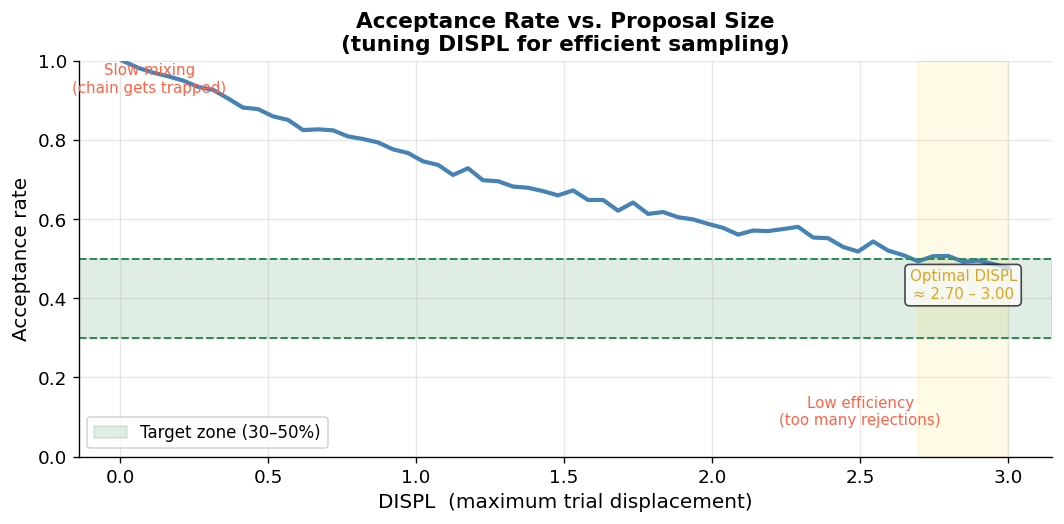

In [6]:
# acceptance rate vs. displacement size in the toy model
displ_values = np.linspace(0.01, 3.0, 60)
acc_rates = []

n_test = 5000
T_test = 0.8

for d in displ_values:
    x = 0.0
    n_acc = 0
    for _ in range(n_test):
        x_new = x + d * (np.random.random() - 0.5)
        dU = U_toy(x_new) - U_toy(x)
        if dU <= 0 or np.random.random() < np.exp(-dU / T_test):
            x = x_new
            n_acc += 1
    acc_rates.append(n_acc / n_test)

acc_rates = np.array(acc_rates)

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(displ_values, acc_rates, color='steelblue', linewidth=2.5)
ax.axhspan(0.30, 0.50, alpha=0.15, color='seagreen', label='Target zone (30–50%)')
ax.axhline(0.30, color='seagreen', linestyle='--', linewidth=1.2)
ax.axhline(0.50, color='seagreen', linestyle='--', linewidth=1.2)

# optimal region
opt_mask = (acc_rates >= 0.30) & (acc_rates <= 0.50)
if opt_mask.any():
    opt_range = displ_values[opt_mask]
    ax.axvspan(opt_range[0], opt_range[-1], alpha=0.1, color='gold')
    ax.annotate(f'Optimal DISPL\n≈ {opt_range[0]:.2f} – {opt_range[-1]:.2f}',
                xy=((opt_range[0]+opt_range[-1])/2, 0.40),
                fontsize=9, ha='center', color='goldenrod',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

ax.annotate('Slow mixing\n(chain gets trapped)', xy=(0.1, 0.92),
            fontsize=9, color='tomato', ha='center')
ax.annotate('Low efficiency\n(too many rejections)', xy=(2.5, 0.08),
            fontsize=9, color='tomato', ha='center')

ax.set_xlabel('DISPL  (maximum trial displacement)')
ax.set_ylabel('Acceptance rate')
ax.set_title('Acceptance Rate vs. Proposal Size\n(tuning DISPL for efficient sampling)',
             fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

---
## 5. Convergence and Mixing Diagnostics

A Markov chain started from an arbitrary configuration needs time to **equilibrate** —
to forget its initial state and start sampling from the true stationary distribution.
This initial phase is called **burn-in** and is discarded from statistical averages.

Two key diagnostics:

- **Energy time series**: the running mean should stabilize to a plateau. The burn-in
  ends approximately where the plateau begins.
- **Block averaging**: the trajectory is divided into blocks of size `NSUB`. The standard
  deviation of block means estimates the true sampling error, correcting for autocorrelation.
  Once block averages are stable, the chain has converged.

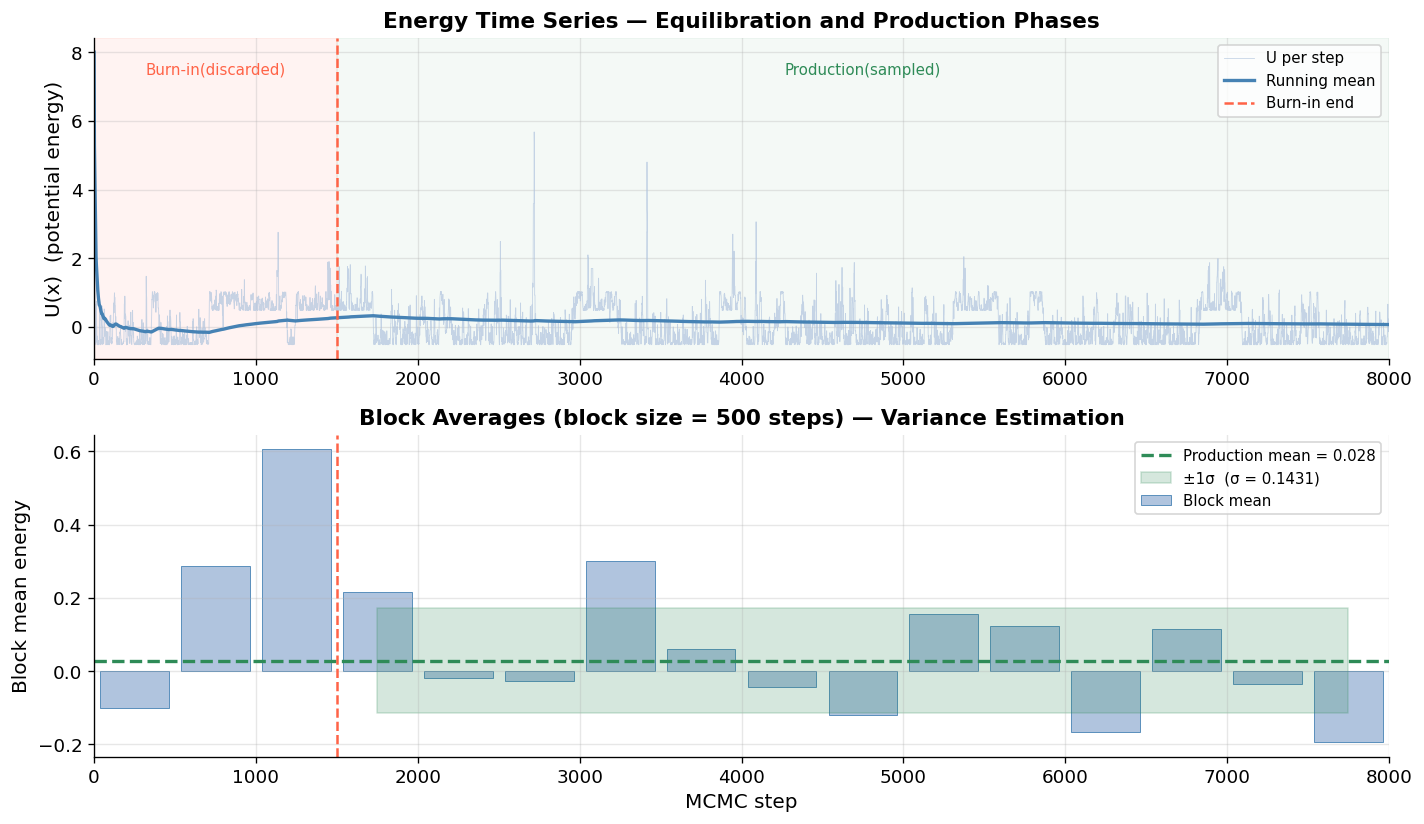

Production block mean : 0.0285
Block std  (σ)        : 0.1431   ← sampling error estimate
Number of blocks      : 13


In [7]:
# toy MCMC trajectory to show equilibration + production
np.random.seed(7)

T_conv  = 0.7
displ_c = 0.5
x_c     = 2.0        # start far from equilibrium
n_total = 8000
NSUB    = 500        # block size

traj    = [x_c]
energies = [U_toy(x_c)]

for _ in range(n_total):
    xn  = x_c + displ_c * (np.random.random() - 0.5)
    dU  = U_toy(xn) - U_toy(x_c)
    if dU <= 0 or np.random.random() < np.exp(-dU / T_conv):
        x_c = xn
    traj.append(x_c)
    energies.append(U_toy(x_c))

energies = np.array(energies)
steps    = np.arange(len(energies))

# running mean
running_mean = np.cumsum(energies) / (steps + 1)

# block averages
n_blocks    = n_total // NSUB
block_means = [energies[1 + k*NSUB : 1 + (k+1)*NSUB].mean() for k in range(n_blocks)]
block_steps = [(k + 0.5) * NSUB for k in range(n_blocks)]
block_std   = np.std(block_means)
equilib_end = 1500   # approximate burn-in

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

# energy time series
axes[0].plot(steps, energies, color='lightsteelblue', linewidth=0.5, alpha=0.7, label='U per step')
axes[0].plot(steps, running_mean, color='steelblue', linewidth=2.0, label='Running mean')
axes[0].axvline(equilib_end, color='tomato', linestyle='--', linewidth=1.5, label='Burn-in end')
axes[0].axvspan(0, equilib_end, alpha=0.07, color='tomato')
axes[0].axvspan(equilib_end, n_total, alpha=0.05, color='seagreen')
axes[0].text(equilib_end/2, energies.max()*0.92, 'Burn-in(discarded)',
             ha='center', color='tomato', fontsize=9)
axes[0].text(equilib_end + (n_total-equilib_end)/2, energies.max()*0.92,
             'Production(sampled)', ha='center', color='seagreen', fontsize=9)
axes[0].set_ylabel('U(x)  (potential energy)')
axes[0].set_title('Energy Time Series — Equilibration and Production Phases', fontweight='bold')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].set_xlim(0, n_total)

# block averages
prod_blocks  = [(m, s) for m, s in zip(block_means, block_steps) if s > equilib_end]
prod_means   = [m for m, s in prod_blocks]
prod_steps_x = [s for m, s in prod_blocks]

axes[1].bar(block_steps, block_means, width=NSUB*0.85, color='lightsteelblue',
            edgecolor='steelblue', linewidth=0.5, label='Block mean')
axes[1].axhline(np.mean(prod_means), color='seagreen', linewidth=2.0,
                linestyle='--', label=f'Production mean = {np.mean(prod_means):.3f}')
axes[1].axvline(equilib_end, color='tomato', linestyle='--', linewidth=1.5)
axes[1].fill_between(prod_steps_x,
                     np.mean(prod_means) - np.std(prod_means),
                     np.mean(prod_means) + np.std(prod_means),
                     alpha=0.2, color='seagreen',
                     label=f'±1σ  (σ = {np.std(prod_means):.4f})')
axes[1].set_xlabel('MCMC step')
axes[1].set_ylabel('Block mean energy')
axes[1].set_title(f'Block Averages (block size = {NSUB} steps) — Variance Estimation',
                  fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, n_total)

plt.tight_layout()
plt.show()

print(f"Production block mean : {np.mean(prod_means):.4f}")
print(f"Block std  (σ)        : {np.std(prod_means):.4f}   ← sampling error estimate")
print(f"Number of blocks      : {len(prod_means)}")

### Why block averaging works

Raw step-to-step energy values are **autocorrelated** — each step is similar to the previous one.
Simply taking the standard deviation of all steps would **underestimate** the true error.

Block averaging reduces autocorrelation: if blocks are long enough (longer than the
autocorrelation time), block means are approximately independent. The standard deviation
of block means is then an unbiased estimate of the sampling error.

In the simulation engine, `NSUB` controls the block size. The output file `uav.dat`
contains one row per block, enabling post-hoc convergence analysis.

---
## 6. Simulation Parameters Reference

The file `mc.in` controls all aspects of the simulation. Below is a reference of
each parameter, its role in the MCMC algorithm, and typical values.

In [8]:
import pandas as pd

params = {
    'Parameter': ['N', 'RHO', 'NMOVE', 'NSUB', 'DISPL', 'NFDR', 'LFDR', 'NRUN'],
    'Description': [
        'Number of particles',
        'Reduced number density  ρ* = N σ³ / V',
        'Total MCMC steps',
        'Block size for variance estimation',
        'Max trial displacement  (units of σ)',
        'g(r) sampling frequency (every N steps)',
        'Enable/disable g(r) sampling',
        'Start mode: 0 = lattice,  1 = resume'
    ],
    'Typical value': ['108 – 864', '0.3 – 0.9', '10⁵ – 10⁶', '10³ – 10⁴',
                      '0.1 – 0.5', '500 – 2000', 'True', '0 (first run)'],
    'Effect on sampling': [
        'Larger N → better statistics, higher cost O(N)',
        'Higher ρ → denser system, slower mixing',
        'More steps → lower variance, longer runtime',
        'Larger blocks → better error estimates',
        'Controls acceptance rate (target 30–50%)',
        'Higher frequency → smoother g(r), higher cost',
        '—',
        'NRUN=1 uses mc.new from previous run'
    ]
}

df = pd.DataFrame(params)
df.index = df.index + 1
print(df.to_string(index=False))

Parameter                             Description Typical value                             Effect on sampling
        N                     Number of particles     108 – 864 Larger N → better statistics, higher cost O(N)
      RHO   Reduced number density  ρ* = N σ³ / V     0.3 – 0.9        Higher ρ → denser system, slower mixing
    NMOVE                        Total MCMC steps     10⁵ – 10⁶    More steps → lower variance, longer runtime
     NSUB      Block size for variance estimation     10³ – 10⁴         Larger blocks → better error estimates
    DISPL    Max trial displacement  (units of σ)     0.1 – 0.5       Controls acceptance rate (target 30–50%)
     NFDR g(r) sampling frequency (every N steps)    500 – 2000  Higher frequency → smoother g(r), higher cost
     LFDR            Enable/disable g(r) sampling          True                                              —
     NRUN    Start mode: 0 = lattice,  1 = resume 0 (first run)           NRUN=1 uses mc.new from previous run


---
## Summary

| Concept | Role in this engine |
|---|---|
| Markov chain | Sequence of particle configurations |
| Stationary distribution | Boltzmann distribution $\propto e^{-U/kT}$ |
| Proposal | Uniform displacement in $[-\Delta/2, +\Delta/2]$ |
| Acceptance criterion | Metropolis-Hastings |
| Variance reduction | Block averaging over `NSUB`-step blocks |
| Estimators | Mean energy, heat capacity, g(r), compressibility Z |

**Next notebook →** `02_simulation_walkthrough.ipynb`: step-by-step simulation run with 
live monitoring of convergence and acceptance rate.